In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm
import joblib

# Load the engineered data
df = pd.read_csv('../data/processed/featured_sales_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print("Data Loaded. Shape:", df.shape)

Data Loaded. Shape: (14994, 18)


In [2]:
# Define the target (Log Demand) and features (Log Price + Controls)
# We use log-log because the coefficient of log_price IS the elasticity.
y_elasticity = df['log_demand']
X_elasticity = df[['log_price', 'competitor_diff', 'promotion_intensity', 'ad_spend']]

# Add a constant (intercept) for OLS
X_elasticity = sm.add_constant(X_elasticity)

# Fit the OLS model
elasticity_model = sm.OLS(y_elasticity, X_elasticity).fit()

# Extract the elasticity coefficient
price_elasticity = elasticity_model.params['log_price']

print(elasticity_model.summary())
print(f"\n\n--- KEY FINDING ---")
print(f"Price Elasticity of Demand: {price_elasticity:.4f}")

# Interpretation logic for the Executive Summary later
if price_elasticity < -1:
    print("Interpretation: Demand is ELASTIC (High sensitivity). a 1% price hike drops volume by >1%.")
else:
    print("Interpretation: Demand is INELASTIC (Low sensitivity). Price changes have smaller impact on volume.")

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     7995.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:33:41   Log-Likelihood:                 10528.
No. Observations:               14994   AIC:                        -2.105e+04
Df Residuals:                   14989   BIC:                        -2.101e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.8025    

MAE: 1.92
R² Score: 0.71


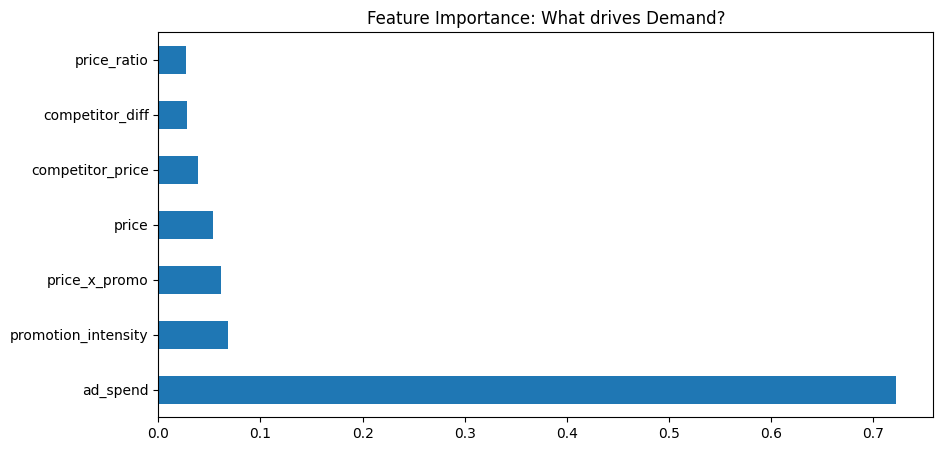

Model saved to src/demand_model.pkl


In [3]:
# Prepare Data for ML
# We want to predict 'estimated_sales' (Volume), not the log version
X_ml = df[['price', 'competitor_price', 'promotion_intensity', 'ad_spend', 'competitor_diff', 'price_ratio', 'price_x_promo']]
y_ml = df['estimated_sales']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
preds = rf_model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"R² Score: {r2_score(y_test, preds):.2f}")

# Feature Importance (Bonus for 'Analytical Rigor')
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Feature Importance: What drives Demand?")
plt.show()

# Save the model for the Dashboard
joblib.dump(rf_model, '../src/demand_model.pkl')
print("Model saved to src/demand_model.pkl")

In [4]:
def optimize_price(current_row, model, min_price=10, max_price=100):
    """
    Finds the optimal price for a specific scenario (row of data)
    to maximize REVENUE.
    """
    # Create a range of possible prices to test
    price_range = np.linspace(min_price, max_price, 100)
    
    # Replicate the row for each price point
    scenario_df = pd.DataFrame([current_row] * len(price_range))
    scenario_df['price'] = price_range
    
    # Recalculate feature engineering dependent on price
    # Note: In a real prod env, this should be a robust pipeline. 
    # Here, we manually update the simple engineered features.
    scenario_df['competitor_diff'] = scenario_df['price'] - scenario_df['competitor_price']
    scenario_df['price_ratio'] = scenario_df['price'] / scenario_df['competitor_price']
    scenario_df['price_x_promo'] = scenario_df['price'] * scenario_df['promotion_intensity']
    
    # Predict Demand using our trained model
    predicted_demand = model.predict(scenario_df[X_ml.columns])
    
    # Calculate Projected Revenue
    projected_revenue = price_range * predicted_demand
    
    # Find the winner
    best_idx = np.argmax(projected_revenue)
    optimal_price = price_range[best_idx]
    max_revenue = projected_revenue[best_idx]
    
    return optimal_price, max_revenue

# Test it on a random recent row
latest_row = X_test.iloc[0].copy() # Grab a test case
opt_price, opt_rev = optimize_price(latest_row, rf_model)

print(f"Current Price: ${latest_row['price']:.2f}")
print(f"Optimal Price: ${opt_price:.2f}")
print(f"Projected Max Revenue: ${opt_rev:.2f}")

Current Price: $56.75
Optimal Price: $100.00
Projected Max Revenue: $2588.00
